# Image Preprocessing Experiments for all CNNS

* VGG16
* ResNet50
* DenseNet121
* MobileNetV2
* EfficientNet-B0

In [ ]:
# Fixed seed
tf.keras.utils.set_random_seed(123)
tf.config.experimental.enable_op_determinism()

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121, MobileNetV2, EfficientNetB0
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import cv2
import sys
import os

In [ ]:
# Clone the github repository with the source code into this notebook
!git clone https://github.com/Avneetkaur16/CM3070_Final_Project.git
%cd CM3070_Final_Project

Cloning into 'CM3070_Final_Project'...
remote: Enumerating objects: 718, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 718 (delta 7), reused 16 (delta 7), pack-reused 693 (from 2)
Receiving objects: 100% (718/718), 23.33 MiB | 31.64 MiB/s, done.
Resolving deltas: 100% (350/350), done.
/content/CM3070_Final_Project


In [ ]:
# Add path to the source code
sys.path.append('/content/CM3070_Final_Project')

In [ ]:
# Import source code functions from repository code
from src.image_preprocessing.image_preprocessors import IMAGE_PREPROCESSORS
from src.utils import *
from src.dataset.dataset import generate_class_weight_dict
from src.workflows.dataset_generation import *
from src.workflows.training_and_evaluation import *
from src.common_model_functions import *
from src.experimental_results_functions import generate_results_metrics_df, store_experiment_results
from src.visualizations import *
from src.constants import BATCH_SIZE, CLASSES, PREDICTION_THRESHOLD, EXPERIMENTAL_EPOCHS

In [ ]:
# Mount the google drive for dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzip and extract training and validation datasets (containing images) and store them in the local memory
!unzip -q "/content/drive/MyDrive/CBISDDSM/train_dataset.zip" -d "/content/extracted_train_data"
!unzip -q "/content/drive/MyDrive/CBISDDSM/val_dataset.zip" -d "/content/extracted_val_data"

In [ ]:
# New dataset root path
dataset_root = "/content/drive/MyDrive/CBISDDSM"

In [ ]:
# Extract training and validation metadata CSV files from drive and store them as dataframes
train_df = pd.read_csv(dataset_root + "/train_data.csv")
val_df = pd.read_csv(dataset_root + "/val_data.csv")

In [ ]:
# Update 'image_path' of all dataframes with new image path source
train_df['new_image_path'] = train_df['image_path'].apply(update_image_path_training)
val_df['new_image_path'] = val_df['image_path'].apply(update_image_path_validation)

In [ ]:
# Print pathology distribution in each set
print(train_df['pathology'].value_counts())
print(val_df['pathology'].value_counts())

pathology
0.0    1371
1.0     904
Name: count, dtype: int64
pathology
0.0    357
1.0    230
Name: count, dtype: int64


In [ ]:
# Validation set true labels for evaluation
val_true_labels = val_df['pathology'].to_numpy()

In [ ]:
# CSV Files to store all experimental results
results_file_path = "/content/drive/MyDrive/CM3070_Final_Project_Experiment_Results/image_preprocessing_experiment_results.csv"

In [ ]:
# Buffer size for shuffling in training dataset
BUFFER_SIZE = len(train_df)
# No. of training samples in training dataframe for class weight
TOTAL_TRAINING_SAMPLES = len(train_df)

In [ ]:
# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
# Class-Imbalance Handling
class_weights_dict = generate_class_weight_dict(train_df, CLASSES, TOTAL_TRAINING_SAMPLES)

## CLAHE + Median Blur Image Preprocessing Experiment

In [ ]:
# CLAHE + Median Blur + Baseline (resizing + model-specific normalization) preprocessing
clahe_median_blur_preprocessor = IMAGE_PREPROCESSORS['clahe_median_blur']

#### tf.data Dataset Preparation for CLAHE + Median Blur Preprocessing

In [ ]:
# Generate training and validation datasets for the given image preprocessor
train_dataset_ipp1 = dataset_preparation(train_df, clahe_median_blur_preprocessor, BUFFER_SIZE, BATCH_SIZE, training=True)
val_dataset_ipp1 = dataset_preparation(val_df, clahe_median_blur_preprocessor, BUFFER_SIZE, BATCH_SIZE, training=False)

### VGG16

In [ ]:
# Select the VGG16 model
vgg16_model_ipp1 = select_model('vgg16')
# Compile and train the VGG16 model with training data
vgg16_ipp1, _, _ = train_selected_model(vgg16_model_ipp1, train_dataset_ipp1, val_dataset_ipp1, EXPERIMENTAL_EPOCHS, early_stopping, class_weights_dict)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 48s 481ms/step - auc: 0.3952 - loss: 1.0041 - precision: 0.3972 - recall: 0.4104 - val_auc: 0.4613 - val_loss: 0.7230 - val_precision: 0.4749 - val_recall: 0.5348
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 475ms/step - auc: 0.4506 - loss: 0.8220 - precision: 0.4710 - recall: 0.4403 - val_auc: 0.4696 - val_loss: 0.6768 - val_precision: 0.5051 - val_recall: 0.4304
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 44s 502ms/step - auc: 0.4938 - loss: 0.7631 - precision: 0.5210 - recall: 0.4812 - val_auc: 0.4899 - val_loss: 0.6714 - val_precision: 0.5187 - val_recall: 0.4826
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 476ms/step - auc: 0.4923 - loss: 0.7355 - precision: 0.5182 - recall: 0.4878 - val_auc: 0.5037 - val_loss: 0.6329 - val_precision: 0.5701 - val_recall: 0.2652
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 482ms/step - auc: 0.4973 - loss: 0.7265 - precision: 0.5298 - recall: 0.4425 - val_auc: 0.5158 - val_lo

In [ ]:
# Predictions and evaluations using the trained VGG16 model
_, _, metrics_dict_vgg16_ipp1, _ = generate_predictions_and_evaluations(vgg16_ipp1, val_dataset_ipp1, val_true_labels, PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 236ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 239ms/step - auc: 0.5611 - loss: 0.6017 - precision: 0.6212 - recall: 0.3565


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
vgg16_ipp1_results_df = generate_results_metrics_df(
    model_name='VGG16',
    experimental_value='CLAHE + Median Blur',
    eval_metrics=metrics_dict_vgg16_ipp1,
    experiment_type='image_preprocessing'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, vgg16_ipp1_results_df)

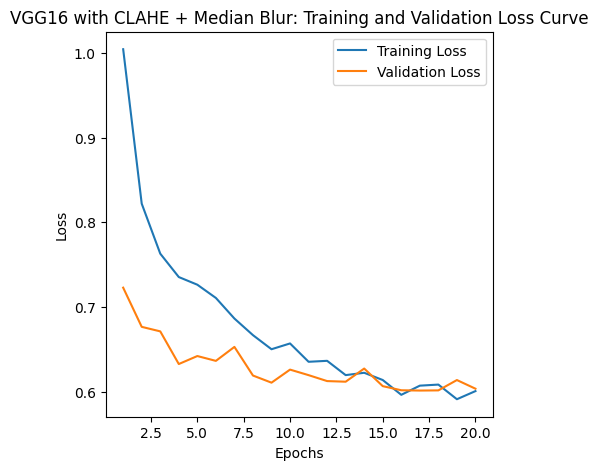

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(vgg16_ipp1.history, 'VGG16', 'CLAHE + Median Blur')

### ResNet50

In [ ]:
# Select the ResNet50 model
resnet50_model_ipp1 = select_model('resnet50')
# Compile and train the ResNet50 model with training data
resnet50_ipp1, _, _ = train_selected_model(resnet50_model_ipp1, train_dataset_ipp1, val_dataset_ipp1, EXPERIMENTAL_EPOCHS, early_stopping, class_weights_dict)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 52s 525ms/step - auc: 0.4821 - loss: 0.6998 - precision: 0.4965 - recall: 0.3905 - val_auc: 0.5962 - val_loss: 0.6040 - val_precision: 0.6475 - val_recall: 0.3913
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 491ms/step - auc: 0.5407 - loss: 0.6393 - precision: 0.5544 - recall: 0.4281 - val_auc: 0.5988 - val_loss: 0.6361 - val_precision: 0.5492 - val_recall: 0.6304
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 494ms/step - auc: 0.5860 - loss: 0.6149 - precision: 0.5989 - recall: 0.4923 - val_auc: 0.6301 - val_loss: 0.5757 - val_precision: 0.7184 - val_recall: 0.3217
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 489ms/step - auc: 0.5790 - loss: 0.6040 - precision: 0.5967 - recall: 0.4436 - val_auc: 0.6472 - val_loss: 0.5977 - val_precision: 0.6418 - val_recall: 0.5609
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 83s 483ms/step - auc: 0.6236 - loss: 0.5853 - precision: 0.6778 - recall: 0.4723 - val_auc: 0.6448 - val_lo

In [ ]:
# Predictions and evaluations using the trained ResNet50 model
_, _, metrics_dict_resnet50_ipp1, _ = generate_predictions_and_evaluations(resnet50_ipp1, val_dataset_ipp1, val_true_labels, PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 346ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 225ms/step - auc: 0.6466 - loss: 0.5530 - precision: 0.7328 - recall: 0.3696


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
resnet50_ipp1_results_df = generate_results_metrics_df(
    model_name='ResNet50',
    experimental_value='CLAHE + Median Blur',
    eval_metrics=metrics_dict_resnet50_ipp1,
    experiment_type='image_preprocessing'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, resnet50_ipp1_results_df)

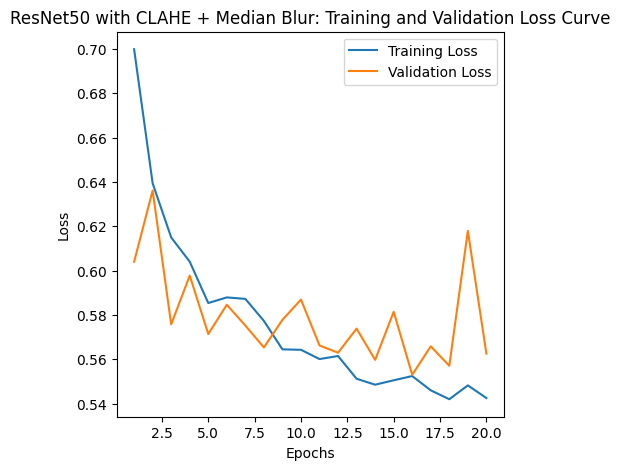

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(resnet50_ipp1.history, 'ResNet50', 'CLAHE + Median Blur')

### DenseNet121

In [ ]:
# Select the DenseNet121 model
densenet121_model_ipp1 = select_model('densenet121')
# Compile and train the DenseNet121 model with training data
densenet121_ipp1, _, _ = train_selected_model(densenet121_model_ipp1, train_dataset_ipp1, val_dataset_ipp1, EXPERIMENTAL_EPOCHS, early_stopping, class_weights_dict)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 60s 575ms/step - auc: 0.4463 - loss: 1.1550 - precision: 0.4562 - recall: 0.4613 - val_auc: 0.5087 - val_loss: 0.6819 - val_precision: 0.5981 - val_recall: 0.2783
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 488ms/step - auc: 0.4796 - loss: 0.9703 - precision: 0.5024 - recall: 0.4646 - val_auc: 0.4913 - val_loss: 0.6673 - val_precision: 0.6203 - val_recall: 0.2130
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 488ms/step - auc: 0.4935 - loss: 0.8626 - precision: 0.5365 - recall: 0.4801 - val_auc: 0.5138 - val_loss: 0.6452 - val_precision: 0.5850 - val_recall: 0.3739
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 489ms/step - auc: 0.4794 - loss: 0.8075 - precision: 0.5073 - recall: 0.4204 - val_auc: 0.5567 - val_loss: 0.6408 - val_precision: 0.5871 - val_recall: 0.3957
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 490ms/step - auc: 0.4973 - loss: 0.7569 - precision: 0.5142 - recall: 0.4192 - val_auc: 0.5409 - val_lo

In [ ]:
# Predictions and evaluations using the trained DenseNet121 model
_, _, metrics_dict_densenet121_ipp1, _ = generate_predictions_and_evaluations(densenet121_ipp1, val_dataset_ipp1, val_true_labels, PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 435ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 233ms/step - auc: 0.5087 - loss: 0.6819 - precision: 0.5981 - recall: 0.2783


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
densenet121_ipp1_results_df = generate_results_metrics_df(
    model_name='DenseNet121',
    experimental_value='CLAHE + Median Blur',
    eval_metrics=metrics_dict_densenet121_ipp1,
    experiment_type='image_preprocessing'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, densenet121_ipp1_results_df)

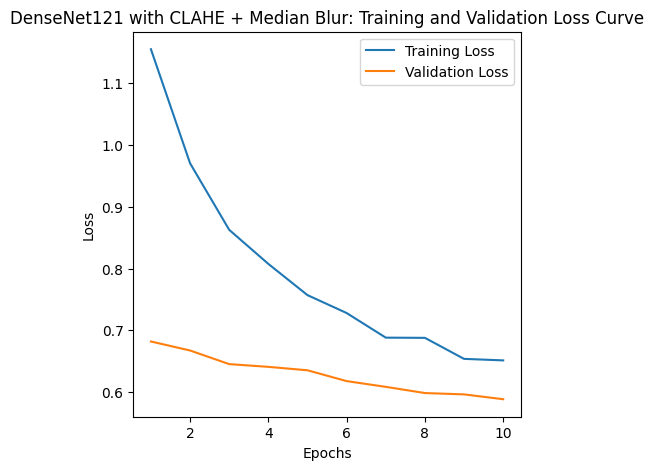

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(densenet121_ipp1.history, 'DenseNet121', 'CLAHE + Median Blur')

### MobileNetV2

In [ ]:
# Select the MobileNetV2 model
mobilenetv2_model_ipp1 = select_model('mobilenetv2')
# Compile and train the MobileNetV2 model with training data
mobilenetv2_ipp1, _, _ = train_selected_model(mobilenetv2_model_ipp1, train_dataset_ipp1, val_dataset_ipp1, EXPERIMENTAL_EPOCHS, early_stopping, class_weights_dict)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 44s 442ms/step - auc: 0.4603 - loss: 0.7041 - precision: 0.4813 - recall: 0.2987 - val_auc: 0.5485 - val_loss: 0.6928 - val_precision: 0.6304 - val_recall: 0.3783
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 415ms/step - auc: 0.4774 - loss: 0.6813 - precision: 0.5086 - recall: 0.2954 - val_auc: 0.5149 - val_loss: 0.7906 - val_precision: 0.4474 - val_recall: 0.7391
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 416ms/step - auc: 0.5131 - loss: 0.6609 - precision: 0.5470 - recall: 0.3473 - val_auc: 0.5739 - val_loss: 0.7086 - val_precision: 0.5354 - val_recall: 0.5261
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 416ms/step - auc: 0.5196 - loss: 0.6561 - precision: 0.5534 - recall: 0.3838 - val_auc: 0.5752 - val_loss: 0.6760 - val_precision: 0.5838 - val_recall: 0.4391
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 414ms/step - auc: 0.5196 - loss: 0.6539 - precision: 0.5453 - recall: 0.3330 - val_auc: 0.5794 - val_loss

In [ ]:
# Predictions and evaluations using the trained MobileNetV2 model
_, _, metrics_dict_mobilenetv2_ipp1, _ = generate_predictions_and_evaluations(mobilenetv2_ipp1, val_dataset_ipp1, val_true_labels, PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 280ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - auc: 0.5485 - loss: 0.6928 - precision: 0.6304 - recall: 0.3783


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
mobilenetv2_ipp1_results_df = generate_results_metrics_df(
    model_name='MobileNetV2',
    experimental_value='CLAHE + Median Blur',
    eval_metrics=metrics_dict_mobilenetv2_ipp1,
    experiment_type='image_preprocessing'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, mobilenetv2_ipp1_results_df)

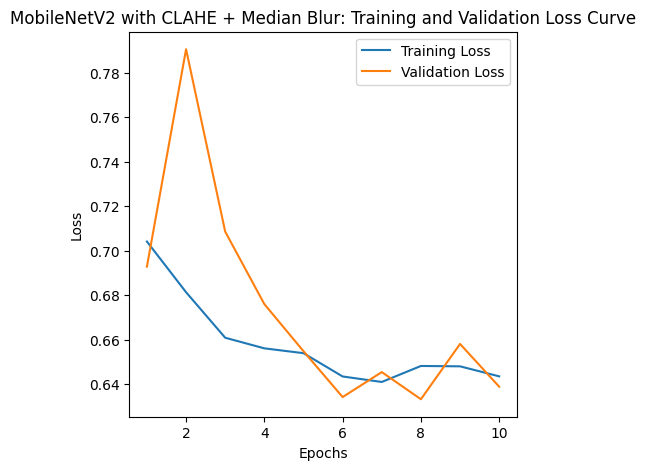

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(mobilenetv2_ipp1.history, 'MobileNetV2', 'CLAHE + Median Blur')

### EfficientNet-B0

In [ ]:
# Select the EfficientNet-B0 model
efficientnetb0_model_ipp1 = select_model('efficientnetb0')
# Compile and train the EfficientNet-B0 model with training data
efficientnetb0_ipp1, _, _ = train_selected_model(efficientnetb0_model_ipp1, train_dataset_ipp1, val_dataset_ipp1, EXPERIMENTAL_EPOCHS, early_stopping,
                                                 class_weights_dict)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 52s 493ms/step - auc: 0.4920 - loss: 0.6633 - precision: 0.5605 - recall: 0.2102 - val_auc: 0.5838 - val_loss: 0.6313 - val_precision: 0.5707 - val_recall: 0.4739
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 463ms/step - auc: 0.5834 - loss: 0.6224 - precision: 0.6310 - recall: 0.4104 - val_auc: 0.5978 - val_loss: 0.6338 - val_precision: 0.5381 - val_recall: 0.5522
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 434ms/step - auc: 0.5610 - loss: 0.6256 - precision: 0.6135 - recall: 0.3529 - val_auc: 0.6187 - val_loss: 0.6419 - val_precision: 0.5466 - val_recall: 0.5870
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 437ms/step - auc: 0.6175 - loss: 0.6001 - precision: 0.6519 - recall: 0.3894 - val_auc: 0.6265 - val_loss: 0.6051 - val_precision: 0.6500 - val_recall: 0.4522
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 433ms/step - auc: 0.6153 - loss: 0.5933 - precision: 0.6425 - recall: 0.4115 - val_auc: 0.6337 - val_lo

In [ ]:
# Predictions and evaluations using the trained EfficientNet-B0 model
_, _, metrics_dict_efficientnetb0_ipp1, _ = generate_predictions_and_evaluations(efficientnetb0_ipp1, val_dataset_ipp1, val_true_labels, PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 310ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - auc: 0.5838 - loss: 0.6313 - precision: 0.5707 - recall: 0.4739


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
efficientnetb0_ipp1_results_df = generate_results_metrics_df(
    model_name='EfficientNet-B0',
    experimental_value='CLAHE + Median Blur',
    eval_metrics=metrics_dict_efficientnetb0_ipp1,
    experiment_type='image_preprocessing'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, efficientnetb0_ipp1_results_df)

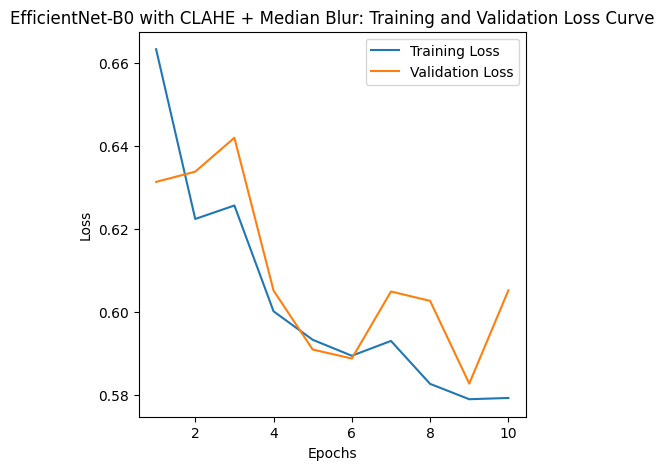

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(efficientnetb0_ipp1.history, 'EfficientNet-B0', 'CLAHE + Median Blur')

## Histogram Equalization + Gaussian Blur Image Preprocessing Experiment

In [ ]:
# Histogram Equalization + Gaussian Blur + Baseline (resizing + model-specific normalization) preprocessing
histo_equalized_gauss_blur_preprocessor = IMAGE_PREPROCESSORS['histogram_equalization_gaussian_blur']

#### tf.data Dataset Preparation for Histogram Equalization + Gaussian Blur Preprocessing

In [ ]:
# Generate training and validation datasets for the given image preprocessor
train_dataset_ipp2 = dataset_preparation(train_df, histo_equalized_gauss_blur_preprocessor, BUFFER_SIZE, BATCH_SIZE, training=True)
val_dataset_ipp2 = dataset_preparation(val_df, histo_equalized_gauss_blur_preprocessor, BUFFER_SIZE, BATCH_SIZE, training=False)

### VGG16

In [ ]:
# Select the VGG16 model
vgg16_model_ipp2 = select_model('vgg16')
# Compile and train the VGG16 model with training data
vgg16_ipp2, _, _ = train_selected_model(vgg16_model_ipp2, train_dataset_ipp2, val_dataset_ipp2, EXPERIMENTAL_EPOCHS, early_stopping, class_weights_dict)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 47s 493ms/step - auc: 0.3941 - loss: 1.0757 - precision: 0.3896 - recall: 0.4060 - val_auc: 0.4536 - val_loss: 0.7200 - val_precision: 0.4643 - val_recall: 0.3957
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 483ms/step - auc: 0.4364 - loss: 0.8800 - precision: 0.4514 - recall: 0.4215 - val_auc: 0.4933 - val_loss: 0.6812 - val_precision: 0.4897 - val_recall: 0.4130
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 495ms/step - auc: 0.4769 - loss: 0.8312 - precision: 0.5077 - recall: 0.4746 - val_auc: 0.5032 - val_loss: 0.6835 - val_precision: 0.4833 - val_recall: 0.4391
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 506ms/step - auc: 0.4808 - loss: 0.7797 - precision: 0.5080 - recall: 0.4945 - val_auc: 0.4932 - val_loss: 0.6471 - val_precision: 0.6154 - val_recall: 0.2435
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 44s 531ms/step - auc: 0.4984 - loss: 0.7559 - precision: 0.5192 - recall: 0.4491 - val_auc: 0.5178 - val_lo

In [ ]:
# Predictions and evaluations using the trained VGG16 model
_, _, metrics_dict_vgg16_ipp2, _ = generate_predictions_and_evaluations(vgg16_ipp2, val_dataset_ipp2, val_true_labels, PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 224ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 222ms/step - auc: 0.5470 - loss: 0.6122 - precision: 0.6522 - recall: 0.2609


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
vgg16_ipp2_results_df = generate_results_metrics_df(
    model_name='VGG16',
    experimental_value='Histogram Equalization + Gaussian Blur',
    eval_metrics=metrics_dict_vgg16_ipp2,
    experiment_type='image_preprocessing'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, vgg16_ipp2_results_df)

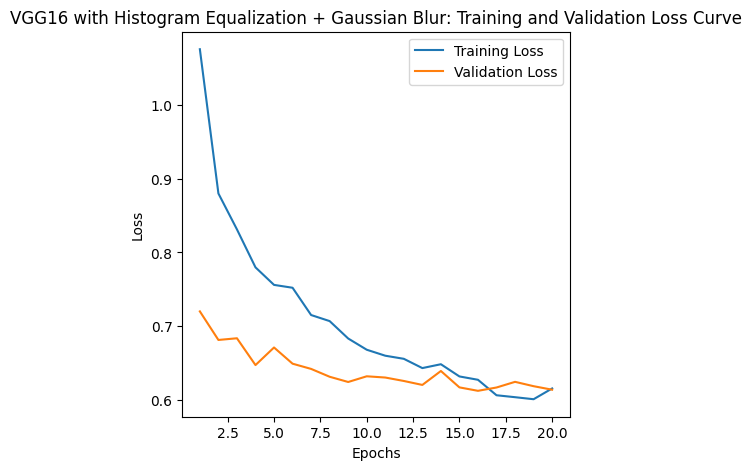

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(vgg16_ipp2.history, 'VGG16', 'Histogram Equalization + Gaussian Blur')

### ResNet50

In [ ]:
# Select the ResNet50 model
resnet50_model_ipp2 = select_model('resnet50')
# Compile and train the ResNet50 model with training data
resnet50_ipp2, _, _ = train_selected_model(resnet50_model_ipp2, train_dataset_ipp2, val_dataset_ipp2, EXPERIMENTAL_EPOCHS, early_stopping, class_weights_dict)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 55s 578ms/step - auc: 0.4739 - loss: 0.7259 - precision: 0.5048 - recall: 0.4071 - val_auc: 0.5807 - val_loss: 0.6047 - val_precision: 0.6286 - val_recall: 0.4783
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 494ms/step - auc: 0.5329 - loss: 0.6568 - precision: 0.5631 - recall: 0.4392 - val_auc: 0.6114 - val_loss: 0.6052 - val_precision: 0.5915 - val_recall: 0.5478
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 503ms/step - auc: 0.5776 - loss: 0.6269 - precision: 0.6094 - recall: 0.5022 - val_auc: 0.6238 - val_loss: 0.5606 - val_precision: 0.7426 - val_recall: 0.3261
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 493ms/step - auc: 0.5601 - loss: 0.6279 - precision: 0.5906 - recall: 0.4325 - val_auc: 0.6196 - val_loss: 0.5775 - val_precision: 0.6842 - val_recall: 0.4522
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 499ms/step - auc: 0.6122 - loss: 0.5994 - precision: 0.6466 - recall: 0.4635 - val_auc: 0.6283 - val_lo

In [ ]:
# Predictions and evaluations using the trained ResNet50 model
_, _, metrics_dict_resnet50_ipp2, _ = generate_predictions_and_evaluations(resnet50_ipp2, val_dataset_ipp2, val_true_labels, PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 349ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 211ms/step - auc: 0.6447 - loss: 0.5504 - precision: 0.7624 - recall: 0.3348


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
resnet50_ipp2_results_df = generate_results_metrics_df(
    model_name='ResNet50',
    experimental_value='Histogram Equalization + Gaussian Blur',
    eval_metrics=metrics_dict_resnet50_ipp2,
    experiment_type='image_preprocessing'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, resnet50_ipp2_results_df)

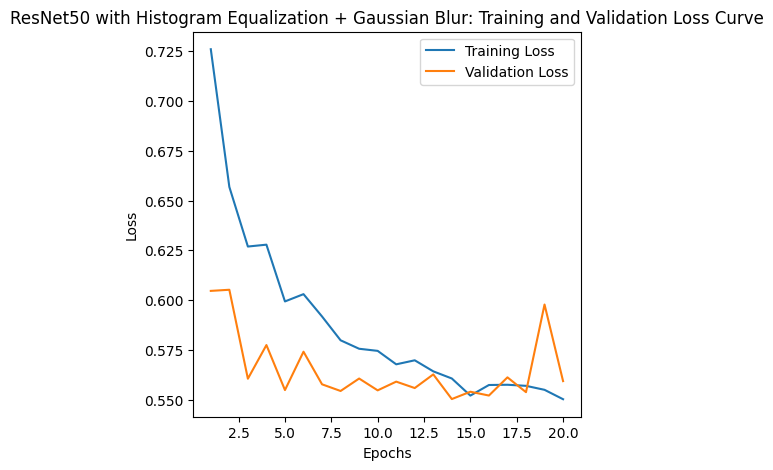

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(resnet50_ipp2.history, 'ResNet50', 'Histogram Equalization + Gaussian Blur')

### DenseNet121

In [ ]:
# Select the DenseNet121 model
densenet121_model_ipp2 = select_model('densenet121')
# Compile and train the DenseNet121 model with training data
densenet121_ipp2, _, _ = train_selected_model(densenet121_model_ipp2, train_dataset_ipp2, val_dataset_ipp2, EXPERIMENTAL_EPOCHS, early_stopping, class_weights_dict)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 60s 578ms/step - auc: 0.4302 - loss: 1.2556 - precision: 0.4431 - recall: 0.4823 - val_auc: 0.5509 - val_loss: 0.6458 - val_precision: 0.5929 - val_recall: 0.3609
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 492ms/step - auc: 0.4504 - loss: 1.0067 - precision: 0.4705 - recall: 0.4668 - val_auc: 0.4620 - val_loss: 0.6771 - val_precision: 0.5918 - val_recall: 0.1261
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 44s 515ms/step - auc: 0.4707 - loss: 0.8909 - precision: 0.5000 - recall: 0.4569 - val_auc: 0.5608 - val_loss: 0.6551 - val_precision: 0.6236 - val_recall: 0.4826
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 489ms/step - auc: 0.4859 - loss: 0.8035 - precision: 0.5133 - recall: 0.4690 - val_auc: 0.5425 - val_loss: 0.6254 - val_precision: 0.6260 - val_recall: 0.3348
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 493ms/step - auc: 0.4918 - loss: 0.7494 - precision: 0.5323 - recall: 0.4369 - val_auc: 0.5596 - val_lo

In [ ]:
# Predictions and evaluations using the trained DenseNet121 model
_, _, metrics_dict_densenet121_ipp2, _ = generate_predictions_and_evaluations(densenet121_ipp2, val_dataset_ipp2, val_true_labels, PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 410ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 218ms/step - auc: 0.5509 - loss: 0.6458 - precision: 0.5929 - recall: 0.3609


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
densenet121_ipp2_results_df = generate_results_metrics_df(
    model_name='DenseNet121',
    experimental_value='Histogram Equalization + Gaussian Blur',
    eval_metrics=metrics_dict_densenet121_ipp2,
    experiment_type='image_preprocessing'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, densenet121_ipp2_results_df)

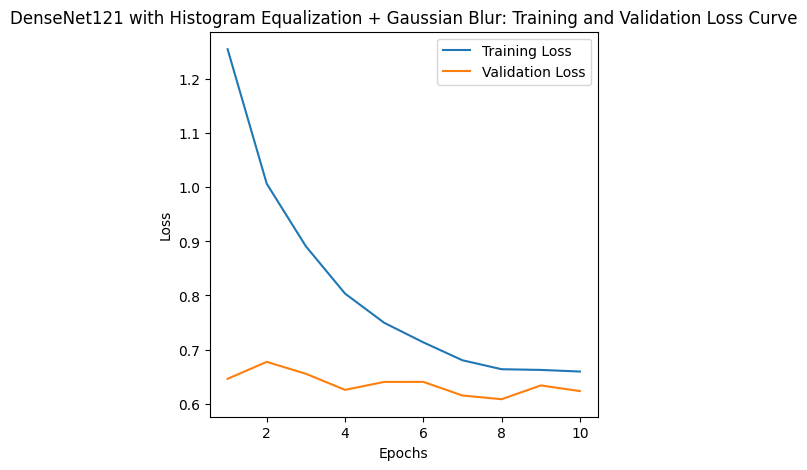

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(densenet121_ipp2.history, 'DenseNet121', 'Histogram Equalization + Gaussian Blur')

### MobileNetV2

In [ ]:
# Select the MobileNetV2 model
mobilenetv2_model_ipp2 = select_model('mobilenetv2')
# Compile and train the MobileNetV2 model with training data
mobilenetv2_ipp2, _, _ = train_selected_model(mobilenetv2_model_ipp2, train_dataset_ipp2, val_dataset_ipp2, EXPERIMENTAL_EPOCHS, early_stopping, class_weights_dict)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 441ms/step - auc: 0.4350 - loss: 0.7226 - precision: 0.4662 - recall: 0.2898 - val_auc: 0.5246 - val_loss: 0.6327 - val_precision: 0.6667 - val_recall: 0.0261
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 416ms/step - auc: 0.4629 - loss: 0.6951 - precision: 0.4926 - recall: 0.2942 - val_auc: 0.5786 - val_loss: 0.6447 - val_precision: 0.6308 - val_recall: 0.3565
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 414ms/step - auc: 0.4952 - loss: 0.6773 - precision: 0.5279 - recall: 0.3142 - val_auc: 0.5759 - val_loss: 0.6249 - val_precision: 0.7031 - val_recall: 0.1957
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 409ms/step - auc: 0.5014 - loss: 0.6742 - precision: 0.5351 - recall: 0.3374 - val_auc: 0.5643 - val_loss: 0.6212 - val_precision: 0.9048 - val_recall: 0.0826
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 413ms/step - auc: 0.5186 - loss: 0.6614 - precision: 0.5608 - recall: 0.3164 - val_auc: 0.5745 - val_loss

In [ ]:
# Predictions and evaluations using the trained MobileNetV2 model
_, _, metrics_dict_mobilenetv2_ipp2, _ = generate_predictions_and_evaluations(mobilenetv2_ipp2, val_dataset_ipp2, val_true_labels, PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 252ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - auc: 0.5246 - loss: 0.6327 - precision: 0.6667 - recall: 0.0261


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
mobilenetv2_ipp2_results_df = generate_results_metrics_df(
    model_name='MobileNetV2',
    experimental_value='Histogram Equalization + Gaussian Blur',
    eval_metrics=metrics_dict_mobilenetv2_ipp2,
    experiment_type='image_preprocessing'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, mobilenetv2_ipp2_results_df)

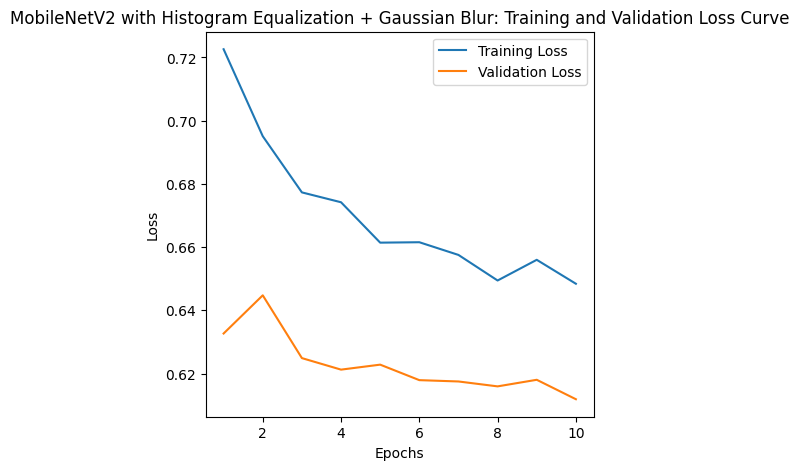

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(mobilenetv2_ipp2.history, 'MobileNetV2', 'Histogram Equalization + Gaussian Blur')

### EfficientNet-B0

In [ ]:
# Select the EfficientNet-B0 model
efficientnetb0_model_ipp2 = select_model('efficientnetb0')
# Compile and train the EfficientNet-B0 model with training data
efficientnetb0_ipp2, _, _ = train_selected_model(efficientnetb0_model_ipp2, train_dataset_ipp2, val_dataset_ipp2,EXPERIMENTAL_EPOCHS, early_stopping,
                                                 class_weights_dict)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 51s 483ms/step - auc: 0.4712 - loss: 0.6703 - precision: 0.5077 - recall: 0.1825 - val_auc: 0.5890 - val_loss: 0.6193 - val_precision: 0.5921 - val_recall: 0.3913
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 441ms/step - auc: 0.5618 - loss: 0.6390 - precision: 0.5972 - recall: 0.3363 - val_auc: 0.6246 - val_loss: 0.6120 - val_precision: 0.6149 - val_recall: 0.4304
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 434ms/step - auc: 0.5797 - loss: 0.6233 - precision: 0.6295 - recall: 0.3496 - val_auc: 0.6263 - val_loss: 0.6143 - val_precision: 0.6041 - val_recall: 0.5174
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 430ms/step - auc: 0.6118 - loss: 0.6075 - precision: 0.6592 - recall: 0.3894 - val_auc: 0.6267 - val_loss: 0.5868 - val_precision: 0.7300 - val_recall: 0.3174
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 441ms/step - auc: 0.5877 - loss: 0.6121 - precision: 0.6283 - recall: 0.3982 - val_auc: 0.6404 - val_lo

In [ ]:
# Predictions and evaluations using the trained EfficientNet-B0 model
_, _, metrics_dict_efficientnetb0_ipp2, _ = generate_predictions_and_evaluations(efficientnetb0_ipp2, val_dataset_ipp2, val_true_labels, PREDICTION_THRESHOLD)

19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 301ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step - auc: 0.5890 - loss: 0.6193 - precision: 0.5921 - recall: 0.3913


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
efficientnetb0_ipp2_results_df = generate_results_metrics_df(
    model_name='EfficientNet-B0',
    experimental_value='Histogram Equalization + Gaussian Blur',
    eval_metrics=metrics_dict_efficientnetb0_ipp2,
    experiment_type='image_preprocessing'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, efficientnetb0_ipp2_results_df)

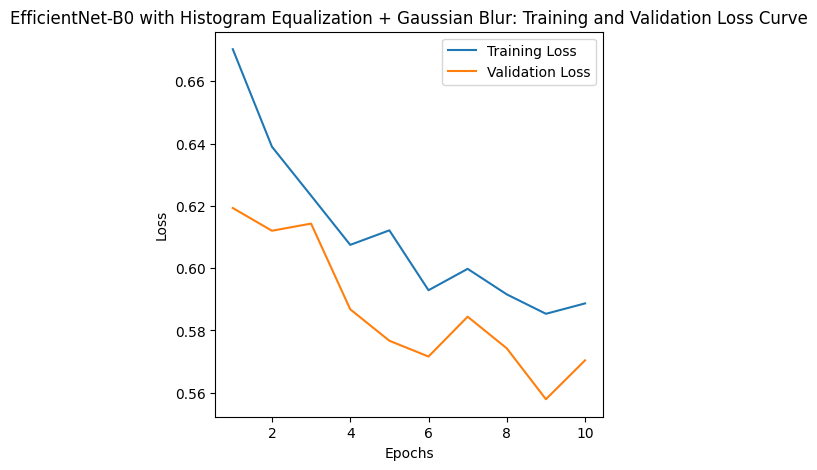

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(efficientnetb0_ipp2.history, 'EfficientNet-B0', 'Histogram Equalization + Gaussian Blur')